In [ ]:
!pip install --upgrade yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# -------------------------------
# Portfolio Risk Analytics System
# Data Acquisition Layer
# -------------------------------

import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime

# -------------------------------
# 1. Configuration
# -------------------------------

INDIAN_STOCKS = [
    "RELIANCE.NS", "TCS.NS", "HDFCBANK.NS", "INFY.NS",
    "ICICIBANK.NS", "HINDUNILVR.NS", "LT.NS", "ITC.NS"
]

US_STOCKS = ["AAPL", "MSFT", "AMZN", "GOOGL"]

BENCHMARKS = ["^NSEI", "^GSPC"]

ALL_TICKERS = INDIAN_STOCKS + US_STOCKS + BENCHMARKS

START_DATE = "2019-01-01"
END_DATE = datetime.today().strftime("%Y-%m-%d")

# -------------------------------
# 2. Data Download Function
# -------------------------------

def fetch_market_data(tickers, start, end):
    try:
        raw = yf.download(
            tickers,
            start=start,
            end=end,
            group_by="ticker",
            auto_adjust=True,
            progress=False
        )

        data = pd.DataFrame()

        for ticker in tickers:
            data[ticker] = raw[ticker]["Close"]

        return data

    except Exception as e:
        print("Error fetching data:", e)
        return None


# -------------------------------
# 3. Execute Download
# -------------------------------

data = fetch_market_data(ALL_TICKERS, START_DATE, END_DATE)

# Validate
if data is not None:
    print("Data successfully downloaded.")
    print("Shape:", data.shape)
    display(data.head())

Data successfully downloaded.
Shape: (1853, 14)


,RELIANCE.NS,TCS.NS,HDFCBANK.NS,INFY.NS,ICICIBANK.NS,HINDUNILVR.NS,LT.NS,ITC.NS,AAPL,MSFT,AMZN,GOOGL,^NSEI,^GSPC
Date,,,,,,,,,,,,,,
2019-01-01,498.490601,1582.166016,504.392578,553.448364,350.957031,1607.500488,1295.537964,201.856064,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-02,491.998260,1599.211792,499.790253,556.777222,351.777130,1592.774048,1280.802612,200.356613,37.503723,94.397171,76.956497,52.338551,10792.500000,2510.030029
2019-01-03,485.928284,1579.796265,495.868927,556.860413,350.474640,1596.165771,1253.398560,199.107056,33.768070,90.924454,75.014000,50.889000,10672.250000,2447.889893
2019-01-04,488.551910,1560.588867,497.195526,550.119690,352.356049,1590.186035,1247.153931,200.606506,35.209618,95.153305,78.769501,53.499275,10727.349609,2531.939941
2019-01-07,491.264496,1578.091675,497.946930,558.982605,354.768097,1593.086304,1243.335693,201.106354,35.131248,95.274673,81.475502,53.392582,10771.799805,2549.689941


In [ ]:
# ==========================================
# STEP 7 — Clean Data + Calculate Returns
# ==========================================

try:
    # Check if data exists
    if 'data' not in globals():
        raise ValueError("Raw price data not found. Please run data download step first.")

    # Step 7A — Clean Data
    print("Cleaning data...")
    data_clean = data.dropna()

    print("Original shape:", data.shape)
    print("Cleaned shape:", data_clean.shape)

    if data_clean.shape[0] == 0:
        raise ValueError("Data cleaning removed all rows. Check data download step.")

    # Step 7B — Calculate Daily Returns
    print("\nCalculating daily returns...")
    returns = data_clean.pct_change().dropna()

    print("Returns shape:", returns.shape)
    print("\nPreview of returns:")
    display(returns.head())

    print("\nStep 7 completed successfully ✅")

except Exception as e:
    print("Error in Step 7:", e)

Cleaning data...
Original shape: (1853, 14)
Cleaned shape: (1706, 14)

Calculating daily returns...
Returns shape: (1705, 14)

Preview of returns:


,RELIANCE.NS,TCS.NS,HDFCBANK.NS,INFY.NS,ICICIBANK.NS,HINDUNILVR.NS,LT.NS,ITC.NS,AAPL,MSFT,AMZN,GOOGL,^NSEI,^GSPC
Date,,,,,,,,,,,,,,
2019-01-03,-0.012337,-0.012141,-0.007846,0.000149,-0.003703,0.002129,-0.021396,-0.006237,-0.099608,-0.036788,-0.025241,-0.027696,-0.011142,-0.024757
2019-01-04,0.005399,-0.012158,0.002675,-0.012105,0.005368,-0.003746,-0.004982,0.007531,0.042690,0.046510,0.050064,0.051294,0.005163,0.034336
2019-01-07,0.005552,0.011216,0.001511,0.016111,0.006845,0.001824,-0.003062,0.002492,-0.002226,0.001276,0.034353,-0.001994,0.004144,0.007010
2019-01-08,-0.000091,-0.002292,-0.008323,-0.002457,0.033859,-0.007899,-0.001156,0.009231,0.019063,0.007250,0.016612,0.008783,0.002818,0.009695
2019-01-09,0.005522,-0.003486,0.006562,0.009029,0.005524,0.007991,0.002785,0.021636,0.016982,0.014300,0.001714,-0.003427,0.004906,0.004098



Step 7 completed successfully ✅


In [ ]:
# ==========================================
# STEP 8 — Annualized Return & Volatility
# ==========================================

TRADING_DAYS = 252  # Standard trading days in a year

# Annualized return
annual_return = returns.mean() * TRADING_DAYS

# Annualized volatility
annual_volatility = returns.std() * np.sqrt(TRADING_DAYS)

# Combine into performance dataframe
performance = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility
})

display(performance.sort_values(by="Annual Return", ascending=False))

,Annual Return,Annual Volatility
AAPL,0.338709,0.315824
GOOGL,0.315842,0.317653
MSFT,0.255207,0.292207
ICICIBANK.NS,0.248067,0.297407
LT.NS,0.220398,0.277071
AMZN,0.209107,0.348447
RELIANCE.NS,0.196745,0.283839
INFY.NS,0.170722,0.280154
^GSPC,0.169745,0.199865
^NSEI,0.143386,0.177310


In [ ]:
# ==========================================
# STEP 9 — Sharpe Ratio
# ==========================================

RISK_FREE_RATE = 0.05  # 5% assumed blended global rate

performance["Sharpe Ratio"] = (
    (performance["Annual Return"] - RISK_FREE_RATE)
    / performance["Annual Volatility"]
)

display(performance.sort_values(by="Sharpe Ratio", ascending=False))

,Annual Return,Annual Volatility,Sharpe Ratio
AAPL,0.338709,0.315824,0.914145
GOOGL,0.315842,0.317653,0.836895
MSFT,0.255207,0.292207,0.702268
ICICIBANK.NS,0.248067,0.297407,0.665979
LT.NS,0.220398,0.277071,0.614998
^GSPC,0.169745,0.199865,0.599128
^NSEI,0.143386,0.177310,0.526681
RELIANCE.NS,0.196745,0.283839,0.517001
AMZN,0.209107,0.348447,0.456618
INFY.NS,0.170722,0.280154,0.430913


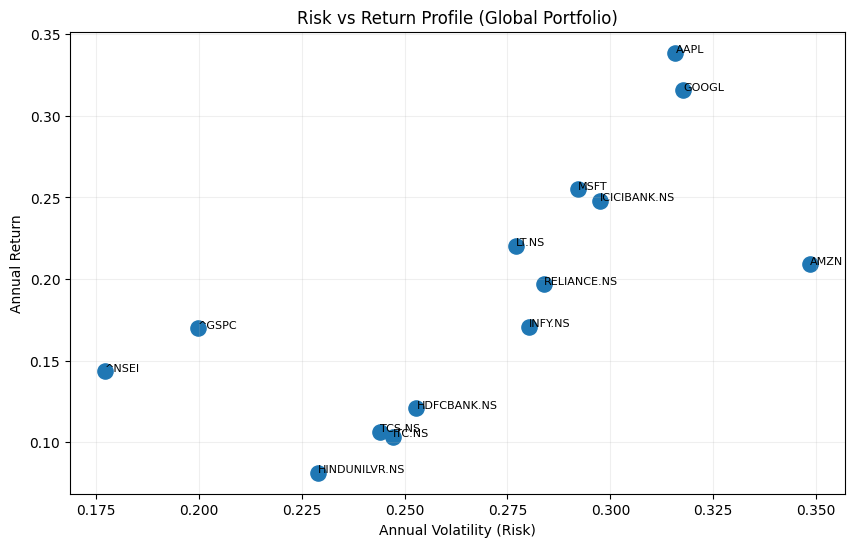

In [ ]:
# ==========================================
# STEP 10 — Risk vs Return Chart
# ==========================================

plt.figure(figsize=(10,6))

plt.scatter(
    performance["Annual Volatility"],
    performance["Annual Return"],
    s=120
)

for stock in performance.index:
    plt.annotate(
        stock,
        (performance.loc[stock, "Annual Volatility"],
         performance.loc[stock, "Annual Return"]),
        fontsize=8
    )

plt.xlabel("Annual Volatility (Risk)")
plt.ylabel("Annual Return")
plt.title("Risk vs Return Profile (Global Portfolio)")
plt.grid(alpha=0.2)
plt.show()

In [ ]:
# ==========================================
# STEP 11 — Prepare Portfolio Data
# ==========================================

# Exclude benchmark indices
portfolio_returns = returns.drop(columns=["^NSEI", "^GSPC"])

# Expected returns vector
mean_returns = portfolio_returns.mean() * 252

# Covariance matrix (annualized)
cov_matrix = portfolio_returns.cov() * 252

num_assets = len(mean_returns)

print("Number of assets:", num_assets)
mean_returns.head()

Number of assets: 12


,0
RELIANCE.NS,0.196745
TCS.NS,0.106468
HDFCBANK.NS,0.120912
INFY.NS,0.170722
ICICIBANK.NS,0.248067


In [ ]:
# ==========================================
# STEP 12 — Random Portfolio Simulation
# ==========================================

num_portfolios = 10000

results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)

    portfolio_return = np.dot(weights, mean_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    results[0, i] = portfolio_return
    results[1, i] = portfolio_volatility
    results[2, i] = portfolio_return / portfolio_volatility  # Sharpe

results_df = pd.DataFrame(results.T, columns=["Return", "Volatility", "Sharpe"])

results_df.head()

,Return,Volatility,Sharpe
0,0.180880,0.159888,1.131290
1,0.194491,0.160763,1.209794
2,0.187384,0.158799,1.180006
3,0.200356,0.168682,1.187772
4,0.171836,0.155258,1.106780


In [ ]:
# ==========================================
# STEP 13 — Optimal Portfolios
# ==========================================

# Maximum Sharpe Ratio portfolio
max_sharpe_idx = results_df["Sharpe"].idxmax()
max_sharpe_portfolio = results_df.loc[max_sharpe_idx]

# Minimum Volatility portfolio
min_vol_idx = results_df["Volatility"].idxmin()
min_vol_portfolio = results_df.loc[min_vol_idx]

print("Maximum Sharpe Portfolio:")
print(max_sharpe_portfolio)

print("\nMinimum Volatility Portfolio:")
print(min_vol_portfolio)

Maximum Sharpe Portfolio:
Return        0.246652
Volatility    0.181644
Sharpe        1.357889
Name: 893, dtype: float64

Minimum Volatility Portfolio:
Return        0.148793
Volatility    0.150945
Sharpe        0.985747
Name: 2398, dtype: float64


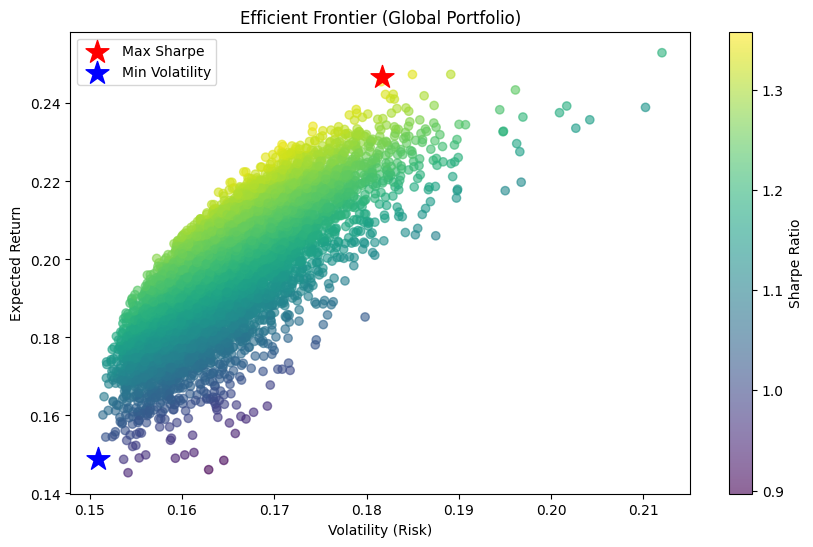

In [ ]:
# ==========================================
# STEP 14 — Efficient Frontier Plot
# ==========================================

plt.figure(figsize=(10,6))

plt.scatter(results_df["Volatility"],
            results_df["Return"],
            c=results_df["Sharpe"],
            cmap="viridis",
            alpha=0.6)

plt.colorbar(label="Sharpe Ratio")

# Mark optimal portfolios
plt.scatter(max_sharpe_portfolio["Volatility"],
            max_sharpe_portfolio["Return"],
            color="red", marker="*", s=300, label="Max Sharpe")

plt.scatter(min_vol_portfolio["Volatility"],
            min_vol_portfolio["Return"],
            color="blue", marker="*", s=300, label="Min Volatility")

plt.xlabel("Volatility (Risk)")
plt.ylabel("Expected Return")
plt.title("Efficient Frontier (Global Portfolio)")
plt.legend()
plt.show()

In [ ]:
# ==========================================
# STEP 15 — Extract Allocation Weights
# ==========================================

# Get weights of max Sharpe portfolio
max_sharpe_weights = weights_record[max_sharpe_idx]

# Get weights of minimum volatility portfolio
min_vol_weights = weights_record[min_vol_idx]

# Create allocation DataFrames
max_sharpe_allocation = pd.DataFrame({
    "Asset": portfolio_returns.columns,
    "Weight (%)": np.round(max_sharpe_weights * 100, 2)
}).sort_values(by="Weight (%)", ascending=False)

min_vol_allocation = pd.DataFrame({
    "Asset": portfolio_returns.columns,
    "Weight (%)": np.round(min_vol_weights * 100, 2)
}).sort_values(by="Weight (%)", ascending=False)

print("Max Sharpe Portfolio Allocation:")
display(max_sharpe_allocation)

print("\nMinimum Volatility Portfolio Allocation:")
display(min_vol_allocation)

Max Sharpe Portfolio Allocation:


,Asset,Weight (%)
4,ICICIBANK.NS,18.08
8,AAPL,17.45
11,GOOGL,14.66
6,LT.NS,11.31
9,MSFT,11.23
3,INFY.NS,8.88
0,RELIANCE.NS,6.05
1,TCS.NS,6.02
2,HDFCBANK.NS,3.48
10,AMZN,2.15



Minimum Volatility Portfolio Allocation:


,Asset,Weight (%)
1,TCS.NS,22.76
7,ITC.NS,15.10
2,HDFCBANK.NS,14.86
5,HINDUNILVR.NS,13.71
9,MSFT,9.32
0,RELIANCE.NS,5.44
8,AAPL,5.18
10,AMZN,5.12
3,INFY.NS,4.73
6,LT.NS,2.74


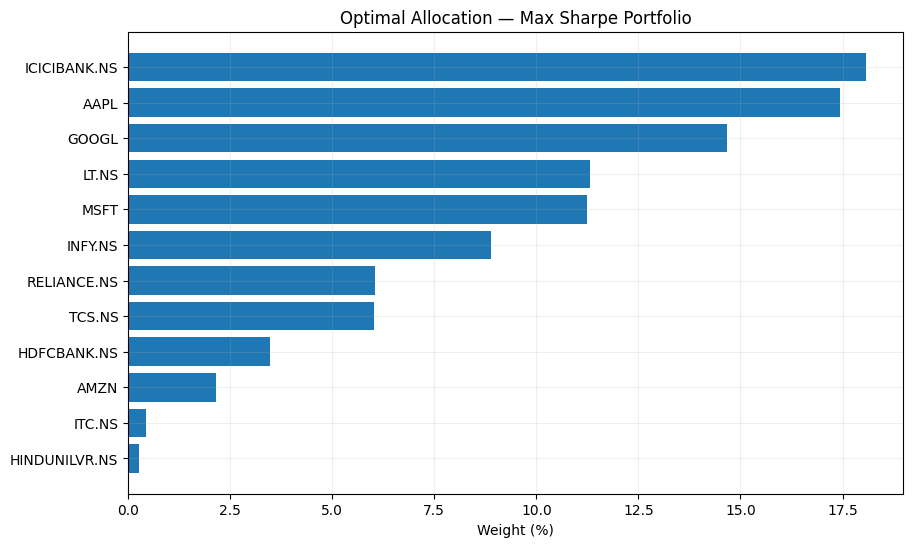

In [ ]:
# ==========================================
# STEP 16 — Allocation Visualization
# ==========================================

plt.figure(figsize=(10,6))

plt.barh(max_sharpe_allocation["Asset"],
         max_sharpe_allocation["Weight (%)"])

plt.xlabel("Weight (%)")
plt.title("Optimal Allocation — Max Sharpe Portfolio")
plt.gca().invert_yaxis()
plt.grid(alpha=0.2)

plt.show()

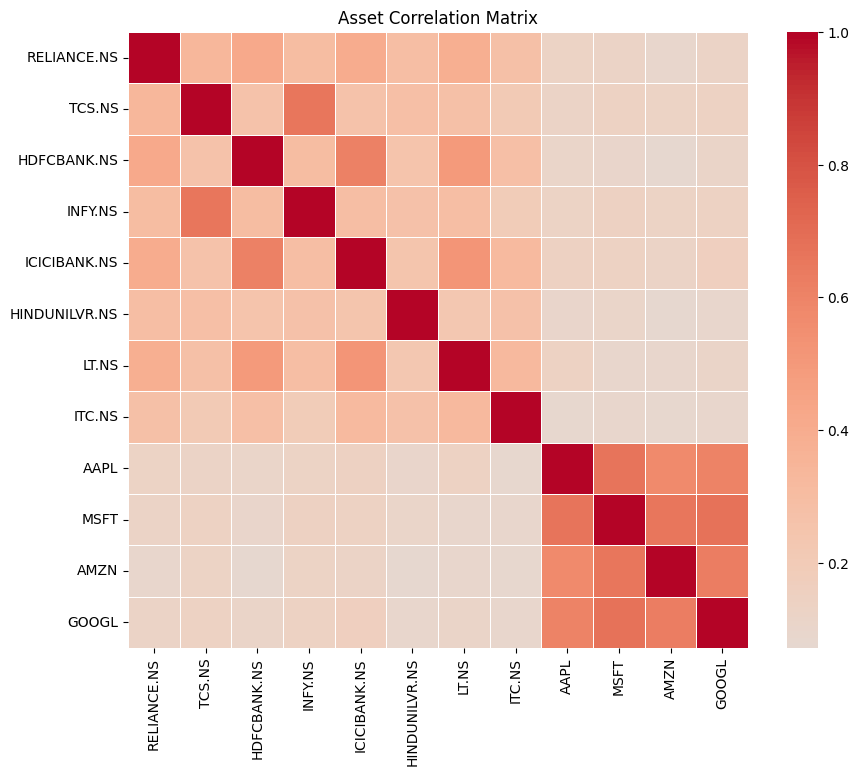

In [ ]:
# ==========================================
# STEP 17 — Correlation Matrix (Safe Version)
# ==========================================

import seaborn as sns

if 'portfolio_returns' not in globals():
    print("portfolio_returns not found. Please run earlier steps.")
else:
    correlation_matrix = portfolio_returns.corr()

    plt.figure(figsize=(10,8))
    sns.heatmap(
        correlation_matrix,
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )

    plt.title("Asset Correlation Matrix")
    plt.show()

In [ ]:
# ==========================================
# STEP 18 — Cross-Market Diversification
# ==========================================

# Separate Indian and US assets
india_assets = portfolio_returns.columns[:8]
us_assets = portfolio_returns.columns[8:]

# Extract cross-correlation block
cross_corr = portfolio_returns[india_assets].corrwith(
    portfolio_returns[us_assets].mean(axis=1)
)

print("Average India vs US Correlation:",
      np.round(cross_corr.mean(), 3))

cross_corr

Average India vs US Correlation: 0.134


,0
RELIANCE.NS,0.137068
TCS.NS,0.152953
HDFCBANK.NS,0.116390
INFY.NS,0.158203
ICICIBANK.NS,0.167915
HINDUNILVR.NS,0.110896
LT.NS,0.127996
ITC.NS,0.102647


In [ ]:
print("""
Interpretation:
Lower cross-market correlation suggests that combining Indian and US equities
may reduce overall portfolio volatility through diversification benefits.
""")


Interpretation:
Lower cross-market correlation suggests that combining Indian and US equities
may reduce overall portfolio volatility through diversification benefits.



In [ ]:
# ==========================================
# STEP 19 — India-Only Portfolio
# ==========================================

india_returns = portfolio_returns.iloc[:, :8]

india_mean = india_returns.mean() * 252
india_cov = india_returns.cov() * 252

# Equal weight allocation
india_weights = np.ones(len(india_mean)) / len(india_mean)

india_return = np.dot(india_weights, india_mean)
india_volatility = np.sqrt(np.dot(india_weights.T, np.dot(india_cov, india_weights)))

print("India-Only Portfolio")
print("Return:", round(india_return,4))
print("Volatility:", round(india_volatility,4))

India-Only Portfolio
Return: 0.156
Volatility: 0.171


In [ ]:
# ==========================================
# STEP 20 — Global Portfolio
# ==========================================

global_mean = portfolio_returns.mean() * 252
global_cov = portfolio_returns.cov() * 252

# Equal weight allocation
global_weights = np.ones(len(global_mean)) / len(global_mean)

global_return = np.dot(global_weights, global_mean)
global_volatility = np.sqrt(np.dot(global_weights.T, np.dot(global_cov, global_weights)))

print("Global Portfolio")
print("Return:", round(global_return,4))
print("Volatility:", round(global_volatility,4))

Global Portfolio
Return: 0.1972
Volatility: 0.1596


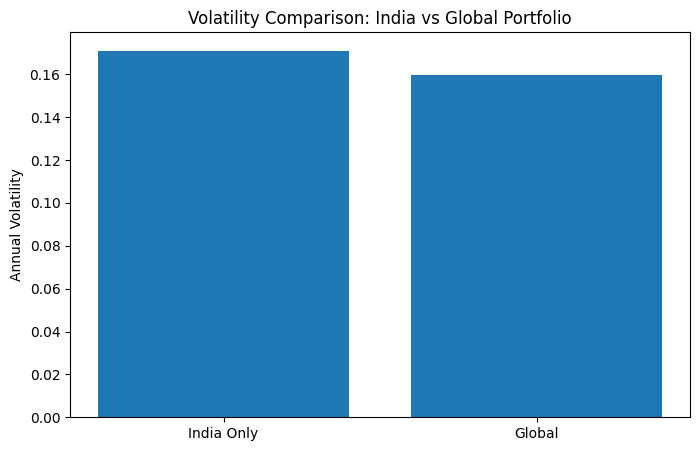

In [ ]:
# ==========================================
# STEP 21 — Diversification Comparison Plot
# ==========================================

labels = ["India Only", "Global"]
returns_compare = [india_return, global_return]
volatility_compare = [india_volatility, global_volatility]

plt.figure(figsize=(8,5))
plt.bar(labels, volatility_compare)
plt.title("Volatility Comparison: India vs Global Portfolio")
plt.ylabel("Annual Volatility")
plt.show()

In [ ]:
# ==========================================
# STEP 22 — Capital Allocation Simulation
# ==========================================

investment_amount = 1000000  # 10 lakh INR

# Use Max Sharpe portfolio weights
allocation_df = max_sharpe_allocation.copy()

allocation_df["Capital Allocation (₹)"] = (
    allocation_df["Weight (%)"] / 100
) * investment_amount

display(allocation_df)

,Asset,Weight (%),Capital Allocation (₹)
4,ICICIBANK.NS,18.08,180800.0
8,AAPL,17.45,174500.0
11,GOOGL,14.66,146600.0
6,LT.NS,11.31,113100.0
9,MSFT,11.23,112300.0
3,INFY.NS,8.88,88800.0
0,RELIANCE.NS,6.05,60500.0
1,TCS.NS,6.02,60200.0
2,HDFCBANK.NS,3.48,34800.0
10,AMZN,2.15,21500.0


In [ ]:
# ==========================================
# STEP 23 — Expected Profit Simulation
# ==========================================

expected_return = max_sharpe_portfolio["Return"]

expected_profit = investment_amount * expected_return

print("Investment Amount: ₹", investment_amount)
print("Expected Annual Return (%):", round(expected_return*100,2))
print("Expected Annual Profit (₹):", round(expected_profit,2))

Investment Amount: ₹ 1000000
Expected Annual Return (%): 24.67
Expected Annual Profit (₹): 246651.82


In [ ]:
# ==========================================
# STEP 24 — Export Final Data
# ==========================================

performance.to_csv("performance_metrics.csv")
results_df.to_csv("efficient_frontier_data.csv")
allocation_df.to_csv("capital_allocation.csv")

print("All files exported successfully.")

All files exported successfully.


In [ ]:
import os

print(os.listdir())

['.config', 'efficient_frontier_data.csv', 'capital_allocation.csv', 'performance_metrics.csv', 'sample_data']
